In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rfa_model as rfa

In [2]:
%matplotlib widget

## Load STLs

In [3]:
stl_dir = Path("../rfa stl")

meshes, sample_parts = rfa.load_and_align_sample_assembly(
    stl_dir,
    alpha_deg=0.0,
)

frame_meshes, frame_parts, frame_info = rfa.load_and_align_grid_frames(
    stl_dir,
    verbose=True,
)

sample_y_bounds, sample_z_bounds = rfa.sample_bounds(meshes)

Grid frame alignment
  fitted center: [-0.00113118 -0.00140144 -0.00109564]
  fitted radius: 0.05887084242766213
  axis before alignment: [ 9.99990913e-01  4.23261006e-03 -5.08542373e-04]
  R_g1: 0.04519042252564098
  R_g2: 0.05792646490184952
  R_g3: 0.07107616160072151


## Load field

In [4]:
field = rfa.load_field_npz("../results/fields/rfa_field_sample_50_g2g3_0_collector50_0p25mm.npz")

print(field.keys())
print("V shape:", field["V"].shape)
print("h:", field["h"])

dict_keys(['x', 'y', 'z', 'h', 'V', 'Ex', 'Ey', 'Ez', 'R_g1', 'R_g2', 'R_g3', 'R_col', 'fixed', 'update_region', 'Vfix', 'owner', 'voltages', 'Vs', 'Vr', 'Vg1', 'Vg2', 'Vg3', 'Vc', 'Vdt'])
V shape: (665, 665, 665)
h: 0.00025


In [7]:
voltages = field["voltages"]

In [6]:
voltages = {
    "Vs": 50.0,
    "Vrod": 0.0,
    "Vg1": 0.0,
    "Vg2": 200.0,
    "Vg3": 200.0,
    "Vc": 1000.0,
    "Vdt": 0.0,
}

In [6]:
field["voltages"] = voltages
field["R_g1"] = frame_info["R_g1"]
field["R_g2"] = frame_info["R_g2"]
field["R_g3"] = frame_info["R_g3"]
field["R_col"] = 0.08255

In [8]:
Ex_interp, Ey_interp, Ez_interp = rfa.build_field_interpolators(field)
Phi_interp = rfa.build_potential_interpolator(field)

p_test = np.array([0.001, 0.0, 0.0])

In [9]:
field = rfa.attach_default_owner_name_map(field)

## Build intersectors

In [10]:
collision_meshes_primary = rfa.build_collision_mesh_dict(
    meshes,
    frame_meshes,
    include_sample=True,
)

collision_mesh_primary, face_owner_primary, intersector_primary = rfa.build_stl_intersector(
    collision_meshes_primary
)

stl_boxes_primary = rfa.build_stl_bounding_boxes(
    collision_meshes_primary,
    padding=1.0e-3,
)

collision_meshes_emit = rfa.build_collision_mesh_dict(
    meshes,
    frame_meshes,
    include_sample=False,
)

collision_mesh_emit, face_owner_emit, intersector_emit = rfa.build_stl_intersector(
    collision_meshes_emit
)

stl_boxes_emit = rfa.build_stl_bounding_boxes(
    collision_meshes_emit,
    padding=1.0e-3,
)

## Samplers

In [11]:
model_dir = Path("../data/jmonsel")
bronstein_dir = Path("../data/bronstein")

yield_models, energy_models, theta_models = rfa.load_default_surface_models(
    model_dir=model_dir,
    bronstein_dir=bronstein_dir,
)

## Run trajectories

In [12]:
grid_transparency = {
    "g1_shell": 0.93,
    "g2_shell": 0.93,
    "g3_shell": 0.93,
}

cascade = rfa.run_cascade_batch_parallel(
    N_primary=10000,
    E0_eV=500,
    field=field,
    Phi_interp=Phi_interp,
    Ex_interp=Ex_interp,
    Ey_interp=Ey_interp,
    Ez_interp=Ez_interp,

    intersector_primary=intersector_primary,
    face_owner_primary=face_owner_primary,
    collision_mesh_primary=collision_mesh_primary,
    stl_boxes_primary=stl_boxes_primary,

    intersector_emit=intersector_emit,
    face_owner_emit=face_owner_emit,
    collision_mesh_emit=collision_mesh_emit,
    stl_boxes_emit=stl_boxes_emit,

    grid_transparency=grid_transparency,

    yield_models=yield_models,
    energy_models=energy_models,
    theta_models=theta_models,
    voltages=voltages,

    sample_y_bounds=sample_y_bounds,
    sample_z_bounds=sample_z_bounds,

    grid_SEY_mult=1.0,
    collector_BSE_mult=1.0,

    max_generation=6,
    max_total_electrons_per_primary=300,
    min_incident_energy_eV=0.5,

    emitted_max_step_fraction_of_h=0.75,
    emitted_dt_max=5.0e-11,
    emitted_max_steps=40000,
    launch_step_fraction_of_h=0.75,

    seed=123,
    n_jobs=24,
    chunk_size=5,
    verbose=10,
)

[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:   21.7s
[Parallel(n_jobs=24)]: Done  13 tasks      | elapsed:   26.4s
[Parallel(n_jobs=24)]: Done  24 tasks      | elapsed:   30.5s
[Parallel(n_jobs=24)]: Done  37 tasks      | elapsed:   34.5s
[Parallel(n_jobs=24)]: Done  50 tasks      | elapsed:   40.7s
[Parallel(n_jobs=24)]: Done  65 tasks      | elapsed:   47.2s
[Parallel(n_jobs=24)]: Done  80 tasks      | elapsed:   52.5s
[Parallel(n_jobs=24)]: Done  97 tasks      | elapsed:   58.5s
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:  1.1min
[Parallel(n_jobs=24)]: Done 133 tasks      | elapsed:  1.2min
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:  1.4min
[Parallel(n_jobs=24)]: Done 173 tasks      | elapsed:  1.5min
[Parallel(n_jobs=24)]: Done 194 tasks      | elapsed:  1.7min
[Parallel(n_jobs=24)]: Done 217 tasks      | elapsed:  1.8min
[Parallel(n_jobs=24)]: Done 240 tasks      | elapsed:  

In [13]:
paths = rfa.save_cascade_batch_tables(
    cascade,
    out_dir="results",
    prefix="cascade_cu_500eV_sample_bias_BSEY_Tg=0p93",
)

paths

{'df_primary': WindowsPath('results/cascade_cu_500eV_sample_bias_BSEY_Tg=0p93_primary.csv'),
 'df_cascade': WindowsPath('results/cascade_cu_500eV_sample_bias_BSEY_Tg=0p93_cascade.csv'),
 'df_cascade_log': WindowsPath('results/cascade_cu_500eV_sample_bias_BSEY_Tg=0p93_cascade_log.csv'),
 'df_grid_events': WindowsPath('results/cascade_cu_500eV_sample_bias_BSEY_Tg=0p93_grid_events.csv'),
 'current_counts': WindowsPath('results/cascade_cu_500eV_sample_bias_BSEY_Tg=0p93_current_counts.csv'),
 'summary': WindowsPath('results/cascade_cu_500eV_sample_bias_BSEY_Tg=0p93_summary.csv')}

## Data analysis

### Load CSV results

In [ ]:
result_dir = Path("../results")
prefix = "cascade_500eV_h025mm_N100000_T09_gen6"  # adjust name

df_cascade = pd.read_csv(result_dir / f"{prefix}_cascade.csv")
df_primary = pd.read_csv(result_dir / f"{prefix}_primary.csv")
current_counts = pd.read_csv(result_dir / f"{prefix}_current_counts.csv", index_col=0)
summary = pd.read_csv(result_dir / f"{prefix}_summary.csv").iloc[0].to_dict()

N_primary = int(summary["N_primary"])

print("N primary:", N_primary)
print("N cascade electrons:", len(df_cascade))
current_counts

In [24]:
df_cascade = cascade["df_cascade"]
df_primary = cascade["df_primary"]
current_counts = cascade["current_counts"]
summary = cascade["summary"]
N_primary = cascade["N_primary"]

In [25]:
cascade["summary"]
cascade["df_cascade"]["reason"].value_counts()
cascade["current_counts"]
cascade["current_counts"]["net_count"].sum()

np.float64(0.0)

In [15]:
ELECTRODE_ORDER = [
    "sample",
    "holder",
    "receiver",
    "rod",
    "grid1",
    "grid2",
    "grid3",
    "collector",
    "drifttube",
    "escaped",
    "unknown",
]


def primary_arrival_per_primary(df_primary, N_primary):
    """
    Primary arrival contribution to sample current.

    For normal runs this should be 1.0, because every primary hits sample.
    """
    if df_primary is None or len(df_primary) == 0:
        return 1.0

    if "reason" in df_primary.columns:
        return float((df_primary["reason"] == "hit_sample").sum()) / float(N_primary)

    return 1.0


def matlab_like_net_per_primary(current_counts, df_primary=None, N_primary=None):
    """
    Convert Python cascade current_counts to MATLAB-style arrived-emitted counts.

    Python:
        net_per_primary = source - terminal

    MATLAB:
        net_count = arrived - emitted

    For emitted/cascade electrons:
        MATLAB-like = -Python

    Then add primary arrival to sample.
    """
    if "net_per_primary" not in current_counts.columns:
        raise ValueError("current_counts must contain net_per_primary")

    if N_primary is None:
        raise ValueError("N_primary is required")

    out = -current_counts["net_per_primary"].copy()
    out = out.reindex(ELECTRODE_ORDER, fill_value=0.0)

    out["sample"] += primary_arrival_per_primary(df_primary, N_primary)

    return out


def true_yields_from_cascade(df_cascade, N_primary):
    """
    True primary-induced sample yields from cascade table.

    Generation 1 = emissions caused by the primary sample hit.
    """
    gen1_sample = df_cascade[
        (df_cascade["generation"] == 1)
        & (df_cascade["source_electrode"] == "sample")
    ]

    true_tey_primary = len(gen1_sample)

    true_bse_primary = int(
        gen1_sample["emission_kind"].astype(str).isin(
            ["BSE", "quantum_reflection", "QR"]
        ).sum()
    )

    true_tey = true_tey_primary / N_primary
    true_bse = true_bse_primary / N_primary

    return {
        "true_tey_primary": true_tey_primary,
        "true_bse_primary": true_bse_primary,
        "true_tey": true_tey,
        "true_bse": true_bse,
    }


def predict_mode_from_cascade(
    df_cascade,
    df_primary,
    current_counts,
    N_primary,
    mode="TEY",
):
    """
    MATLAB-like measured-current prediction and correction factor.

    Valid modes:
        TEY
        sample_bias_BSE
        grid_bias_BSE
    """
    mode = str(mode)

    if mode not in ["TEY", "sample_bias_BSE", "grid_bias_BSE"]:
        raise ValueError("mode must be TEY, sample_bias_BSE, or grid_bias_BSE")

    matlab_net = matlab_like_net_per_primary(
        current_counts,
        df_primary=df_primary,
        N_primary=N_primary,
    )

    measured_sample_side = (
        matlab_net["sample"]
        + matlab_net["holder"]
        + matlab_net["receiver"]
    )

    measured_rfa_all = (
        matlab_net["collector"]
        + matlab_net["drifttube"]
        + matlab_net["rod"]
        + matlab_net["grid1"]
        + matlab_net["grid2"]
        + matlab_net["grid3"]
    )

    measured_rfa_after_retarding = (
        matlab_net["collector"]
        + matlab_net["grid2"]
        + matlab_net["grid3"]
    )

    measured_total_current = measured_sample_side + measured_rfa_all

    y = true_yields_from_cascade(df_cascade, N_primary)

    if mode == "TEY":
        true_yield = y["true_tey"]
        true_primary_count = y["true_tey_primary"]
        measured_yield = measured_rfa_all / measured_total_current

    elif mode == "sample_bias_BSE":
        true_yield = y["true_bse"]
        true_primary_count = y["true_bse_primary"]
        measured_yield = measured_rfa_all / measured_total_current

    elif mode == "grid_bias_BSE":
        true_yield = y["true_bse"]
        true_primary_count = y["true_bse_primary"]
        measured_yield = measured_rfa_after_retarding / measured_total_current

    correction_factor = true_yield / measured_yield

    return {
        "mode": mode,
        "N_primary": N_primary,

        "true_tey_primary": y["true_tey_primary"],
        "true_bse_primary": y["true_bse_primary"],
        "true_primary_count_for_mode": true_primary_count,

        "measured_sample_side": measured_sample_side * N_primary,
        "measured_total_current": measured_total_current * N_primary,
        "measured_rfa_all": measured_rfa_all * N_primary,
        "measured_rfa_after_retarding": measured_rfa_after_retarding * N_primary,

        "measured_sample_side_per_primary": measured_sample_side,
        "measured_total_current_per_primary": measured_total_current,
        "measured_rfa_all_per_primary": measured_rfa_all,
        "measured_rfa_after_retarding_per_primary": measured_rfa_after_retarding,

        "true_yield": true_yield,
        "measured_yield": measured_yield,
        "correction_factor": correction_factor,
    }


def predict_all_modes_from_cascade(
    df_cascade,
    df_primary,
    current_counts,
    N_primary,
):
    rows = []

    for mode in ["TEY", "sample_bias_BSE", "grid_bias_BSE"]:
        rows.append(
            predict_mode_from_cascade(
                df_cascade=df_cascade,
                df_primary=df_primary,
                current_counts=current_counts,
                N_primary=N_primary,
                mode=mode,
            )
        )

    return pd.DataFrame(rows)

### TEY

In [26]:
field_mode = "TEY"

df_pred = pd.DataFrame([
    predict_mode_from_cascade(
        df_cascade=df_cascade,
        df_primary=df_primary,
        current_counts=current_counts,
        N_primary=N_primary,
        mode=field_mode,
    )
])

df_pred[cols]

,mode,N_primary,true_tey_primary,true_bse_primary,measured_sample_side,measured_total_current,measured_rfa_all,measured_rfa_after_retarding,true_yield,measured_yield,correction_factor
0,TEY,1000,1703,416,-705.0,997.0,1702.0,1522.0,1.703,1.707121,0.997586


In [27]:
tey_cols = [
    "mode",
    "N_primary",
    "true_tey_primary",
    "measured_sample_side",
    "measured_total_current",
    "measured_rfa_all",
    "true_yield",
    "measured_yield",
    "correction_factor",
]

df_pred[tey_cols]

,mode,N_primary,true_tey_primary,measured_sample_side,measured_total_current,measured_rfa_all,true_yield,measured_yield,correction_factor
0,TEY,1000,1703,-705.0,997.0,1702.0,1.703,1.707121,0.997586


In [29]:
cc = cascade["current_counts"].copy()

# Make sure per-primary columns exist
for col in ["source_count", "terminal_count", "net_count"]:
    if col in cc.columns:
        cc[col + "_per_primary"] = cc[col] / N_primary

cc

,source_count,terminal_count,net_count,source_per_primary,terminal_per_primary,net_per_primary,source_count_per_primary,terminal_count_per_primary,net_count_per_primary
sample,1709.0,-1.0,1708.0,1.709,-0.001,1.708,1.709,-0.001,1.708
holder,5.0,-7.0,-2.0,0.005,-0.007,-0.002,0.005,-0.007,-0.002
receiver,1.0,-2.0,-1.0,0.001,-0.002,-0.001,0.001,-0.002,-0.001
rod,1.0,-8.0,-7.0,0.001,-0.008,-0.007,0.001,-0.008,-0.007
grid1,7.0,-163.0,-156.0,0.007,-0.163,-0.156,0.007,-0.163,-0.156
grid2,0.0,-101.0,-101.0,0.000,-0.101,-0.101,0.000,-0.101,-0.101
grid3,1.0,-115.0,-114.0,0.001,-0.115,-0.114,0.001,-0.115,-0.114
collector,589.0,-1896.0,-1307.0,0.589,-1.896,-1.307,0.589,-1.896,-1.307
drifttube,5.0,-22.0,-17.0,0.005,-0.022,-0.017,0.005,-0.022,-0.017
escaped,0.0,-3.0,-3.0,0.000,-0.003,-0.003,0.000,-0.003,-0.003


In [30]:
matlab_net = matlab_like_net_per_primary(
    current_counts=cascade["current_counts"],
    df_primary=cascade["df_primary"],
    N_primary=N_primary,
)

df_currents = pd.DataFrame({
    "python_source_minus_terminal_per_primary": cascade["current_counts"]["net_per_primary"],
    "matlab_arrived_minus_emitted_per_primary": matlab_net,
})

df_currents["matlab_arrived_minus_emitted_count"] = (
    df_currents["matlab_arrived_minus_emitted_per_primary"] * N_primary
)

df_currents

,python_source_minus_terminal_per_primary,matlab_arrived_minus_emitted_per_primary,matlab_arrived_minus_emitted_count
sample,1.708,-0.708,-708.0
holder,-0.002,0.002,2.0
receiver,-0.001,0.001,1.0
rod,-0.007,0.007,7.0
grid1,-0.156,0.156,156.0
grid2,-0.101,0.101,101.0
grid3,-0.114,0.114,114.0
collector,-1.307,1.307,1307.0
drifttube,-0.017,0.017,17.0
escaped,-0.003,0.003,3.0


### Return current

In [31]:
df = cascade["df_cascade"]

sample_side = ["sample", "holder", "receiver"]

df_return = df[df["terminal_electrode"].isin(sample_side)].copy()

print("Number returned to sample side:", len(df_return))
print("Per primary:", len(df_return) / N_primary)

df_return["terminal_electrode"].value_counts()

Number returned to sample side: 10
Per primary: 0.01


terminal_electrode
holder      7
receiver    2
sample      1
Name: count, dtype: int64

In [32]:
return_by_terminal = (
    df_return
    .groupby("terminal_electrode")
    .size()
    .rename("count")
    .to_frame()
)

return_by_terminal["per_primary"] = return_by_terminal["count"] / N_primary
return_by_terminal

,count,per_primary
terminal_electrode,,
holder,7,0.007
receiver,2,0.002
sample,1,0.001


In [33]:
return_by_generation = (
    df_return
    .groupby(["generation", "terminal_electrode"])
    .size()
    .rename("count")
    .reset_index()
)

return_by_generation["per_primary"] = return_by_generation["count"] / N_primary
return_by_generation

,generation,terminal_electrode,count,per_primary
0,1,holder,6,0.006
1,2,holder,1,0.001
2,2,receiver,2,0.002
3,2,sample,1,0.001


In [34]:
df_return_sample = df[df["terminal_electrode"] == "sample"]

print("Returned to sample:", len(df_return_sample))
print("Returned to sample per primary:", len(df_return_sample) / N_primary)

df_return_sample[[
    "primary_index",
    "electron_id",
    "parent_id",
    "generation",
    "source_electrode",
    "emission_kind",
    "terminal_electrode",
    "reason",
    "E_emit_eV",
    "KE_hit_eV",
]].head(20)

Returned to sample: 1
Returned to sample per primary: 0.001


,primary_index,electron_id,parent_id,generation,source_electrode,emission_kind,terminal_electrode,reason,E_emit_eV,KE_hit_eV
1303,558,2,1,2,holder,SE,sample,hit_fixed,1.02573,1.025733


### Escaped

In [36]:
df_escaped = df[df["terminal_electrode"] == "escaped"].copy()

print("Escaped electrons:", len(df_escaped))
print("Escaped per primary:", len(df_escaped) / N_primary)

df_escaped["reason"].value_counts()

Escaped electrons: 3
Escaped per primary: 0.003


reason
field_nan    3
Name: count, dtype: int64

In [35]:
loss_like_reasons = [
    "left_grid",
    "left_update_region",
    "escaped",
    "field_nan",
    "nan_state",
    "nan_step",
    "rk_nan",
]

df_losses = df[
    (df["terminal_electrode"].isin(["escaped", "unknown"]))
    | (df["reason"].isin(loss_like_reasons))
].copy()

loss_table = (
    df_losses
    .groupby(["terminal_electrode", "reason"])
    .size()
    .rename("count")
    .reset_index()
)

loss_table["per_primary"] = loss_table["count"] / N_primary
loss_table

,terminal_electrode,reason,count,per_primary
0,escaped,field_nan,3,0.003


In [37]:
def summarize_returns_and_losses(cascade, N_primary):
    df = cascade["df_cascade"]

    groups = {
        "returned_to_sample": df["terminal_electrode"].eq("sample"),
        "returned_to_holder": df["terminal_electrode"].eq("holder"),
        "returned_to_receiver": df["terminal_electrode"].eq("receiver"),
        "returned_to_sample_side": df["terminal_electrode"].isin(["sample", "holder", "receiver"]),
        "escaped": df["terminal_electrode"].eq("escaped"),
        "unknown": df["terminal_electrode"].eq("unknown"),
    }

    rows = []

    for name, mask in groups.items():
        count = int(mask.sum())
        rows.append({
            "category": name,
            "count": count,
            "per_primary": count / N_primary,
            "percent_of_cascade_electrons": 100 * count / len(df),
        })

    return pd.DataFrame(rows)

summary_returns_losses = summarize_returns_and_losses(cascade, N_primary)
summary_returns_losses

,category,count,per_primary,percent_of_cascade_electrons
0,returned_to_sample,1,0.001,0.043141
1,returned_to_holder,7,0.007,0.301984
2,returned_to_receiver,2,0.002,0.086281
3,returned_to_sample_side,10,0.010,0.431406
4,escaped,3,0.003,0.129422
5,unknown,0,0.000,0.000000


### Prediction table

In [16]:
df_pred = predict_all_modes_from_cascade(
    df_cascade=df_cascade,
    df_primary=df_primary,
    current_counts=current_counts,
    N_primary=N_primary,
)

cols = [
    "mode",
    "N_primary",
    "true_tey_primary",
    "true_bse_primary",
    "measured_sample_side",
    "measured_total_current",
    "measured_rfa_all",
    "measured_rfa_after_retarding",
    "true_yield",
    "measured_yield",
    "correction_factor",
]

df_pred[cols]

,mode,N_primary,true_tey_primary,true_bse_primary,measured_sample_side,measured_total_current,measured_rfa_all,measured_rfa_after_retarding,true_yield,measured_yield,correction_factor
0,TEY,100,171,39,-71.0,99.0,170.0,157.0,1.71,1.717172,0.995824
1,sample_bias_BSE,100,171,39,-71.0,99.0,170.0,157.0,0.39,1.717172,0.227118
2,grid_bias_BSE,100,171,39,-71.0,99.0,170.0,157.0,0.39,1.585859,0.245924


### Current distribution table

In [17]:
matlab_net = matlab_like_net_per_primary(
    current_counts,
    df_primary=df_primary,
    N_primary=N_primary,
)

df_current = pd.DataFrame({
    "python_source_minus_terminal_per_primary": current_counts["net_per_primary"],
    "matlab_arrived_minus_emitted_per_primary": matlab_net,
})

df_current["matlab_arrived_minus_emitted_count"] = (
    df_current["matlab_arrived_minus_emitted_per_primary"] * N_primary
)

df_current

,python_source_minus_terminal_per_primary,matlab_arrived_minus_emitted_per_primary,matlab_arrived_minus_emitted_count
sample,1.71,-0.71,-71.0
holder,0.00,-0.00,-0.0
receiver,0.00,-0.00,-0.0
rod,0.00,-0.00,-0.0
grid1,-0.13,0.13,13.0
grid2,-0.07,0.07,7.0
grid3,-0.13,0.13,13.0
collector,-1.37,1.37,137.0
drifttube,0.00,-0.00,-0.0
escaped,-0.01,0.01,1.0


### Plot predicted MATLAB-like current distribution

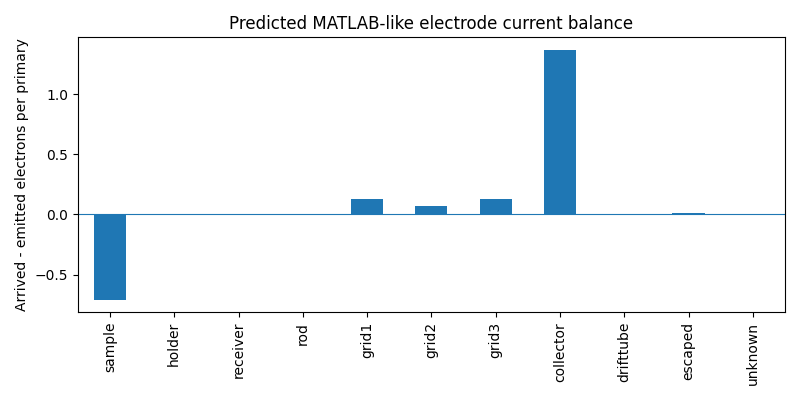

In [18]:
ax = df_current["matlab_arrived_minus_emitted_per_primary"].plot(
    kind="bar",
    figsize=(8, 4),
)

ax.axhline(0, linewidth=0.8)
ax.set_ylabel("Arrived - emitted electrons per primary")
ax.set_title("Predicted MATLAB-like electrode current balance")
plt.tight_layout()

### Print summary: sample bias

In [19]:
pred_sample_bias = predict_mode_from_cascade(
    df_cascade=df_cascade,
    df_primary=df_primary,
    current_counts=current_counts,
    N_primary=N_primary,
    mode="sample_bias_BSE",
)

for k, v in pred_sample_bias.items():
    print(f"{k:35s}: {v}")

mode                               : sample_bias_BSE
N_primary                          : 100
true_tey_primary                   : 171
true_bse_primary                   : 39
true_primary_count_for_mode        : 39
measured_sample_side               : -71.0
measured_total_current             : 99.00000000000003
measured_rfa_all                   : 170.00000000000003
measured_rfa_after_retarding       : 157.00000000000003
measured_sample_side_per_primary   : -0.71
measured_total_current_per_primary : 0.9900000000000002
measured_rfa_all_per_primary       : 1.7000000000000002
measured_rfa_after_retarding_per_primary: 1.5700000000000003
true_yield                         : 0.39
measured_yield                     : 1.717171717171717
correction_factor                  : 0.22711764705882356


### Print summary: grid bias

In [20]:
pred_grid_bias = predict_mode_from_cascade(
    df_cascade=df_cascade,
    df_primary=df_primary,
    current_counts=current_counts,
    N_primary=N_primary,
    mode="grid_bias_BSE",
)

for k, v in pred_grid_bias.items():
    print(f"{k:35s}: {v}")

mode                               : grid_bias_BSE
N_primary                          : 100
true_tey_primary                   : 171
true_bse_primary                   : 39
true_primary_count_for_mode        : 39
measured_sample_side               : -71.0
measured_total_current             : 99.00000000000003
measured_rfa_all                   : 170.00000000000003
measured_rfa_after_retarding       : 157.00000000000003
measured_sample_side_per_primary   : -0.71
measured_total_current_per_primary : 0.9900000000000002
measured_rfa_all_per_primary       : 1.7000000000000002
measured_rfa_after_retarding_per_primary: 1.5700000000000003
true_yield                         : 0.39
measured_yield                     : 1.5858585858585859
correction_factor                  : 0.2459235668789809


## Current prediction

In [14]:
I_exp = {
    "sample":    -3.6141e-10,
    "grid1":      4.8526e-12,
    "grid2":      2.4404e-12,
    "grid3":      5.0760e-12,
    "collector":  2.2169e-10,
    "drifttube":  2.9134e-12,
    "rod":        2.9896e-12,
}

fit_electrodes = [
    "grid1",
    "grid2",
    "grid3",
    "collector",
    "drifttube",
    "rod",
]

I_exp_rfa_total = sum(I_exp[e] for e in fit_electrodes)

f_exp = {
    e: I_exp[e] / I_exp_rfa_total
    for e in fit_electrodes
}

pd.DataFrame({
    "I_exp_A": I_exp,
}).loc[["sample"] + fit_electrodes]

,I_exp_A
sample,-3.614100e-10
grid1,4.852600e-12
grid2,2.440400e-12
grid3,5.076000e-12
collector,2.216900e-10
drifttube,2.913400e-12
rod,2.989600e-12


In [15]:
I_exp['collector']/(I_exp['grid1']+I_exp['grid2']+I_exp['grid3']+I_exp['rod']+I_exp['drifttube']+I_exp['collector'])

0.9238546103132995

In [16]:
df_exp_frac = pd.DataFrame({
    "electrode": fit_electrodes,
    "I_exp_A": [I_exp[e] for e in fit_electrodes],
    "f_exp": [f_exp[e] for e in fit_electrodes],
})

df_exp_frac

,electrode,I_exp_A,f_exp
0,grid1,4.852600e-12,0.020222
1,grid2,2.440400e-12,0.010170
2,grid3,5.076000e-12,0.021153
3,collector,2.216900e-10,0.923855
4,drifttube,2.913400e-12,0.012141
5,rod,2.989600e-12,0.012459


In [17]:
ELECTRODE_ORDER = [
    "sample",
    "holder",
    "receiver",
    "rod",
    "grid1",
    "grid2",
    "grid3",
    "collector",
    "drifttube",
    "escaped",
    "unknown",
]


def primary_arrival_per_primary(df_primary, N_primary):
    if df_primary is None or len(df_primary) == 0:
        return 1.0

    if "reason" in df_primary.columns:
        return float((df_primary["reason"] == "hit_sample").sum()) / float(N_primary)

    return 1.0


def matlab_like_net_per_primary(current_counts, df_primary=None, N_primary=None):
    """
    Convert Python source-minus-terminal accounting to measured-current-like
    arrived-minus-emitted accounting.

    Adds primary electron arrival to the sample.
    """
    out = -current_counts["net_per_primary"].copy()
    out = out.reindex(ELECTRODE_ORDER, fill_value=0.0)

    out["sample"] += primary_arrival_per_primary(df_primary, N_primary)

    return out


def current_fractions_from_cascade(cascade, N_primary):
    """
    Return measured-current-like RFA-side fractions from a cascade result.
    """
    matlab_net = matlab_like_net_per_primary(
        cascade["current_counts"],
        df_primary=cascade["df_primary"],
        N_primary=N_primary,
    )

    I_sim = matlab_net.reindex(["sample"] + fit_electrodes, fill_value=0.0)

    rfa_total = I_sim.loc[fit_electrodes].sum()

    f_sim = I_sim.loc[fit_electrodes] / rfa_total

    return I_sim, f_sim, rfa_total

In [18]:
def score_fractions(f_sim, f_exp, fit_electrodes):
    """
    Compute several fit metrics comparing simulated and experimental fractions.
    """
    rows = []

    for e in fit_electrodes:
        fs = float(f_sim[e])
        fe = float(f_exp[e])

        rows.append({
            "electrode": e,
            "f_sim": fs,
            "f_exp": fe,
            "diff": fs - fe,
            "relative_diff": (fs - fe) / fe,
        })

    df = pd.DataFrame(rows)

    # Old MATLAB-like score: relative residuals for every electrode.
    chi2_relative = float(np.sum(df["relative_diff"] ** 2))

    # Safer score: avoid over-weighting tiny channels.
    # 0.01 means a 1 percentage-point floor in fraction space.
    sigma_floor = 0.01

    chi2_fraction_floor = float(
        np.sum((df["diff"] / np.maximum(df["f_exp"], sigma_floor)) ** 2)
    )

    return df, chi2_relative, chi2_fraction_floor

In [19]:
def run_one_fit_point(
    grid_SEY_mult,
    collector_BSE_mult,
    Tg,
    N_primary=1000,
    E0_eV=1000,
    seed=123,
    n_jobs=24,
    chunk_size=5,
    max_generation=6,
):
    grid_transparency = {
        "g1_shell": Tg,
        "g2_shell": Tg,
        "g3_shell": Tg,
    }

    cascade = rfa.run_cascade_batch_parallel(
        N_primary=N_primary,
        E0_eV=E0_eV,

        field=field,
        Phi_interp=Phi_interp,
        Ex_interp=Ex_interp,
        Ey_interp=Ey_interp,
        Ez_interp=Ez_interp,

        intersector_primary=intersector_primary,
        face_owner_primary=face_owner_primary,
        collision_mesh_primary=collision_mesh_primary,
        stl_boxes_primary=stl_boxes_primary,

        intersector_emit=intersector_emit,
        face_owner_emit=face_owner_emit,
        collision_mesh_emit=collision_mesh_emit,
        stl_boxes_emit=stl_boxes_emit,

        grid_transparency=grid_transparency,

        yield_models=yield_models,
        energy_models=energy_models,
        theta_models=theta_models,
        voltages=voltages,

        sample_y_bounds=sample_y_bounds,
        sample_z_bounds=sample_z_bounds,

        grid_SEY_mult=grid_SEY_mult,
        collector_BSE_mult=collector_BSE_mult,

        max_generation=max_generation,
        max_total_electrons_per_primary=300,
        min_incident_energy_eV=0.5,

        emitted_max_step_fraction_of_h=0.75,
        emitted_dt_max=5.0e-11,
        emitted_max_steps=40000,
        launch_step_fraction_of_h=0.75,

        seed=seed,
        n_jobs=n_jobs,
        chunk_size=chunk_size,
        verbose=0,
    )

    I_sim, f_sim, rfa_total = current_fractions_from_cascade(
        cascade,
        N_primary=N_primary,
    )

    df_fit, chi2_relative, chi2_fraction_floor = score_fractions(
        f_sim=f_sim,
        f_exp=f_exp,
        fit_electrodes=fit_electrodes,
    )

    row = {
        "grid_SEY_mult": grid_SEY_mult,
        "collector_BSE_mult": collector_BSE_mult,
        "Tg": Tg,
        "N_primary": N_primary,
        "E0_eV": E0_eV,

        "chi2_relative": chi2_relative,
        "chi2_fraction_floor": chi2_fraction_floor,

        "sim_rfa_total_per_primary": rfa_total,
        "sim_sample_per_primary": I_sim["sample"],

        "charge_balance": cascade["current_counts"]["net_count"].sum(),
        "N_cascade_electrons": len(cascade["df_cascade"]),
    }

    for e in fit_electrodes:
        row[f"f_sim_{e}"] = float(f_sim[e])
        row[f"I_sim_{e}_per_primary"] = float(I_sim[e])

    row["I_sim_sample_per_primary"] = float(I_sim["sample"])

    return row, df_fit, cascade

In [ ]:
Tg_values = [0.91, 0.93, 0.95]
grid_SEY_mult_values = [1.0, 1.5, 2.0, 2.5, 3.0]
collector_BSE_mult_values = [0.5, 0.8, 1.0, 1.5]

N_fit = 10000
E0_fit = 1000

out_dir = Path("results/currents_prediction_scan")
out_dir.mkdir(parents=True, exist_ok=True)

rows = []
fit_tables = {}

total_runs = len(Tg_values) * len(grid_SEY_mult_values) * len(collector_BSE_mult_values)
run_idx = 0

for Tg in Tg_values:
    for grid_SEY_mult in grid_SEY_mult_values:
        for collector_BSE_mult in collector_BSE_mult_values:
            run_idx += 1
    
            print(
                f"Run {run_idx}/{total_runs}: "
                f"grid_SEY_mult={grid_SEY_mult:.3f}, "
                f"collector_BSE_mult={collector_BSE_mult:.3f}, "
                f"Tg={Tg:.3f}",
                flush=True,
            )
    
            row, df_fit, cascade_i = run_one_fit_point(
                grid_SEY_mult=grid_SEY_mult,
                collector_BSE_mult=collector_BSE_mult,
                Tg=Tg,
                N_primary=N_fit,
                E0_eV=E0_fit,
                seed=123,
                n_jobs=24,
                chunk_size=5,
                max_generation=6,
            )
    
            rows.append(row)
            fit_tables[(grid_SEY_mult, collector_BSE_mult)] = df_fit
    
            df_scan = pd.DataFrame(rows)
            df_scan.to_csv(out_dir / "1keV_scan_sample_BSE_results.csv", index=False)
    
            display(df_scan.sort_values("chi2_fraction_floor").head())
    
            df = cascade_i["df_cascade"]
    
            df_sources = (
                df.groupby(["source_owner", "source_electrode"])
                .size()
                .reset_index(name="n")
                .sort_values("n", ascending=False)
            )
            
            df_sources.head(20)

df_scan = pd.DataFrame(rows)
df_scan.sort_values("chi2_fraction_floor")

Run 1/60: grid_SEY_mult=1.000, collector_BSE_mult=0.500, Tg=0.910


,grid_SEY_mult,collector_BSE_mult,Tg,N_primary,E0_eV,chi2_relative,chi2_fraction_floor,sim_rfa_total_per_primary,sim_sample_per_primary,charge_balance,...,I_sim_grid2_per_primary,f_sim_grid3,I_sim_grid3_per_primary,f_sim_collector,I_sim_collector_per_primary,f_sim_drifttube,I_sim_drifttube_per_primary,f_sim_rod,I_sim_rod_per_primary,I_sim_sample_per_primary
0,1.0,0.5,0.91,10000,1000,78.242902,78.242902,0.4934,0.4987,0.0,...,0.0412,0.072558,0.0358,0.720916,0.3557,0.007296,0.0036,0.005472,0.0027,0.4987


Run 2/60: grid_SEY_mult=1.000, collector_BSE_mult=0.800, Tg=0.910


,grid_SEY_mult,collector_BSE_mult,Tg,N_primary,E0_eV,chi2_relative,chi2_fraction_floor,sim_rfa_total_per_primary,sim_sample_per_primary,charge_balance,...,I_sim_grid2_per_primary,f_sim_grid3,I_sim_grid3_per_primary,f_sim_collector,I_sim_collector_per_primary,f_sim_drifttube,I_sim_drifttube_per_primary,f_sim_rod,I_sim_rod_per_primary,I_sim_sample_per_primary
0,1.0,0.5,0.91,10000,1000,78.242902,78.242902,0.4934,0.4987,0.0,...,0.0412,0.072558,0.0358,0.720916,0.3557,0.007296,0.0036,0.005472,0.0027,0.4987
1,1.0,0.8,0.91,10000,1000,84.890948,84.890948,0.4942,0.4977,0.0,...,0.0429,0.078713,0.0389,0.710441,0.3511,0.007285,0.0036,0.005666,0.0028,0.4977


Run 3/60: grid_SEY_mult=1.000, collector_BSE_mult=1.000, Tg=0.910


...

Run 58/60: grid_SEY_mult=3.000, collector_BSE_mult=0.800, Tg=0.950


,grid_SEY_mult,collector_BSE_mult,Tg,N_primary,E0_eV,chi2_relative,chi2_fraction_floor,sim_rfa_total_per_primary,sim_sample_per_primary,charge_balance,...,I_sim_grid2_per_primary,f_sim_grid3,I_sim_grid3_per_primary,f_sim_collector,I_sim_collector_per_primary,f_sim_drifttube,I_sim_drifttube_per_primary,f_sim_rod,I_sim_rod_per_primary,I_sim_sample_per_primary
56,3.0,0.5,0.95,10000,1000,21.683103,21.683103,0.4966,0.4949,0.0,...,0.0252,0.040475,0.0201,0.830246,0.4123,0.007048,0.0035,0.007853,0.0039,0.4949
52,2.5,0.5,0.95,10000,1000,23.584268,23.584268,0.4979,0.4938,0.0,...,0.0260,0.040972,0.0204,0.826270,0.4114,0.006829,0.0034,0.007230,0.0036,0.4938
57,3.0,0.8,0.95,10000,1000,26.173666,26.173666,0.4954,0.4956,0.0,...,0.0272,0.045418,0.0225,0.818732,0.4056,0.006863,0.0034,0.007872,0.0039,0.4956
48,2.0,0.5,0.95,10000,1000,26.247305,26.247305,0.4978,0.4940,0.0,...,0.0271,0.041985,0.0209,0.821012,0.4087,0.006830,0.0034,0.006428,0.0032,0.4940
44,1.5,0.5,0.95,10000,1000,27.807163,27.807163,0.4976,0.4945,0.0,...,0.0273,0.042805,0.0213,0.815314,0.4057,0.006833,0.0034,0.006431,0.0032,0.4945


Run 59/60: grid_SEY_mult=3.000, collector_BSE_mult=1.000, Tg=0.950


,grid_SEY_mult,collector_BSE_mult,Tg,N_primary,E0_eV,chi2_relative,chi2_fraction_floor,sim_rfa_total_per_primary,sim_sample_per_primary,charge_balance,...,I_sim_grid2_per_primary,f_sim_grid3,I_sim_grid3_per_primary,f_sim_collector,I_sim_collector_per_primary,f_sim_drifttube,I_sim_drifttube_per_primary,f_sim_rod,I_sim_rod_per_primary,I_sim_sample_per_primary
56,3.0,0.5,0.95,10000,1000,21.683103,21.683103,0.4966,0.4949,0.0,...,0.0252,0.040475,0.0201,0.830246,0.4123,0.007048,0.0035,0.007853,0.0039,0.4949
52,2.5,0.5,0.95,10000,1000,23.584268,23.584268,0.4979,0.4938,0.0,...,0.0260,0.040972,0.0204,0.826270,0.4114,0.006829,0.0034,0.007230,0.0036,0.4938
57,3.0,0.8,0.95,10000,1000,26.173666,26.173666,0.4954,0.4956,0.0,...,0.0272,0.045418,0.0225,0.818732,0.4056,0.006863,0.0034,0.007872,0.0039,0.4956
48,2.0,0.5,0.95,10000,1000,26.247305,26.247305,0.4978,0.4940,0.0,...,0.0271,0.041985,0.0209,0.821012,0.4087,0.006830,0.0034,0.006428,0.0032,0.4940
44,1.5,0.5,0.95,10000,1000,27.807163,27.807163,0.4976,0.4945,0.0,...,0.0273,0.042805,0.0213,0.815314,0.4057,0.006833,0.0034,0.006431,0.0032,0.4945


Run 60/60: grid_SEY_mult=3.000, collector_BSE_mult=1.500, Tg=0.950


In [21]:
df_scan = pd.DataFrame(rows)

df_scan.sort_values("chi2_fraction_floor")

,grid_SEY_mult,collector_BSE_mult,Tg,N_primary,E0_eV,chi2_relative,chi2_fraction_floor,sim_rfa_total_per_primary,sim_sample_per_primary,charge_balance,...,I_sim_grid2_per_primary,f_sim_grid3,I_sim_grid3_per_primary,f_sim_collector,I_sim_collector_per_primary,f_sim_drifttube,I_sim_drifttube_per_primary,f_sim_rod,I_sim_rod_per_primary,I_sim_sample_per_primary
39,1.5,2.0,0.95,10000,1000,0.572912,0.572912,1.7023,-0.7202,0.0,...,0.0841,0.040475,0.0689,0.823239,1.4014,0.013805,0.0235,0.004641,0.0079,-0.7202
43,2.0,2.0,0.95,10000,1000,0.578966,0.578966,1.7026,-0.7205,0.0,...,0.0760,0.036943,0.0629,0.837190,1.4254,0.014331,0.0244,0.005169,0.0088,-0.7205
38,1.5,1.5,0.95,10000,1000,0.598244,0.598244,1.6958,-0.7102,0.0,...,0.0810,0.038566,0.0654,0.828223,1.4045,0.012914,0.0219,0.004010,0.0068,-0.7102
34,1.0,1.5,0.95,10000,1000,0.614958,0.614958,1.6879,-0.7019,0.0,...,0.0871,0.040761,0.0688,0.817999,1.3807,0.012145,0.0205,0.003732,0.0063,-0.7019
42,2.0,1.5,0.95,10000,1000,0.615617,0.615617,1.6940,-0.7089,0.0,...,0.0741,0.034416,0.0583,0.841677,1.4258,0.013400,0.0227,0.004486,0.0076,-0.7089
30,2.5,1.5,0.93,10000,1000,0.633839,0.633839,1.6971,-0.7124,0.0,...,0.0876,0.041483,0.0704,0.815509,1.3840,0.015674,0.0266,0.005716,0.0097,-0.7124
29,2.5,1.0,0.93,10000,1000,0.634998,0.634998,1.6921,-0.7072,0.0,...,0.0849,0.040009,0.0677,0.820637,1.3886,0.015070,0.0255,0.005082,0.0086,-0.7072
28,2.5,0.5,0.93,10000,1000,0.638639,0.638639,1.7024,-0.7161,0.0,...,0.0831,0.038593,0.0657,0.824424,1.4035,0.014979,0.0255,0.004993,0.0085,-0.7161
35,1.0,2.0,0.95,10000,1000,0.645560,0.645560,1.6957,-0.7124,0.0,...,0.0904,0.042932,0.0728,0.811405,1.3759,0.013564,0.0230,0.004069,0.0069,-0.7124
26,2.0,1.5,0.93,10000,1000,0.655632,0.655632,1.6964,-0.7112,0.0,...,0.0950,0.046569,0.0790,0.798868,1.3552,0.014737,0.0250,0.005011,0.0085,-0.7112


In [22]:
best = df_scan.sort_values("chi2_fraction_floor").iloc[0]

best_tg = float(best["Tg"])
best_grid = float(best["grid_SEY_mult"])
best_col = float(best["collector_BSE_mult"])

print("Best coarse point:")
print("Transparency = ", best_tg)
print("grid_SEY_mult =", best_grid)
print("collector_BSE_mult       =", best_col)
print("score    =", best["chi2_fraction_floor"])

df_best = fit_tables[(best_tg,best_grid, best_col)].copy()
df_best

Best coarse point:
Transparency =  0.95
grid_SEY_mult = 1.5
collector_BSE_mult       = 2.0
score    = 0.5729122474951774


KeyError: (0.95, 1.5, 2.0)

NameError: name 'best_SEY' is not defined

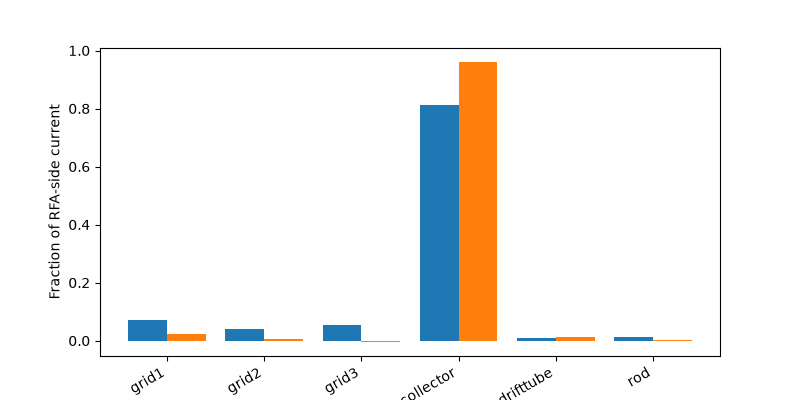

In [21]:
df_plot = df_best.copy()
x = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - 0.2, df_plot["f_exp"], width=0.4, label="Experiment")
ax.bar(x + 0.2, df_plot["f_sim"], width=0.4, label="Simulation")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["electrode"], rotation=30, ha="right")
ax.set_ylabel("Fraction of RFA-side current")
ax.set_title(f"Best coarse fit: SEY_mult={best_SEY:.2f}, Tg={best_Tg:.2f}")
ax.legend()

plt.tight_layout()

In [ ]:
def predicted_amp_table_from_fit(df_fit, I_exp, fit_electrodes):
    I_exp_rfa_total = sum(I_exp[e] for e in fit_electrodes)

    rows = []

    for _, r in df_fit.iterrows():
        e = r["electrode"]

        I_pred = r["f_sim"] * I_exp_rfa_total

        rows.append({
            "electrode": e,
            "I_exp_A": I_exp[e],
            "I_pred_A": I_pred,
            "ratio_pred_exp": I_pred / I_exp[e],
            "f_exp": r["f_exp"],
            "f_sim": r["f_sim"],
        })

    return pd.DataFrame(rows)


df_current_compare = predicted_amp_table_from_fit(
    df_best,
    I_exp=I_exp,
    fit_electrodes=fit_electrodes,
)

df_current_compare

In [ ]:
dfp = df_current_compare.copy()
x = np.arange(len(dfp))

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - 0.2, 1e9 * dfp["I_exp_A"], width=0.4, label="Experiment")
ax.bar(x + 0.2, 1e9 * dfp["I_pred_A"], width=0.4, label="Simulation fit")

ax.set_xticks(x)
ax.set_xticklabels(dfp["electrode"], rotation=30, ha="right")
ax.set_ylabel("Current (nA)")
ax.set_title("RFA-side current distribution")
ax.legend()

plt.tight_layout()

In [ ]:
sey_refined = np.round(
    np.linspace(best_SEY - 0.1, best_SEY + 0.1, 5),
    3,
)

Tg_refined = np.round(
    np.linspace(best_Tg - 0.02, best_Tg + 0.02, 5),
    3,
)

sey_refined = [
    x for x in sey_refined
    if 0.5 <= x <= 1.5
]

Tg_refined = [
    x for x in Tg_refined
    if 0.80 <= x <= 0.99
]

sey_refined, Tg_refined